# Chinese-Zodiac -- a quantitative teardown of lunar calendar market folklore
### FXI 2004-2026 | ^GSPC 1994-2026 | pre-CNY rally | 12-way Bonferroni | HAC inference

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Lucky_Dragon%3F: Busted](https://img.shields.io/badge/Lucky_Dragon%3F-Busted-8b949e?style=flat-square)

The rigorous companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb). Same seven beats, every claim now carrying its standard error. We test (A) whether the 10-day pre-CNY window on FXI and ^GSPC shows a HAC-significant return premium vs a random-window baseline, and (B) whether any zodiac animal produces a Bonferroni-corrected significant annual return difference on FXI. Both tests fail. The effective n per animal is ~3; we quantify exactly how little power that buys.

> **Not investment advice.** Real data: FXI daily auto-adjusted closes, Yahoo Finance, 2004-10-11 to 2026-06-12 (n=5,453); ^GSPC 1994-01-04 to 2026-06-12 (n=8,165). CNY dates hardcoded from the Chinese lunisolar calendar 1990-2026. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from chinese_zodiac import data, strategy as st

HAVE_REAL = False
try:
    ret_fxi = data.fetch_daily("FXI")
    HAVE_REAL = len(ret_fxi) > 100
except Exception:
    ret_fxi = None

print("FXI real cache present:", HAVE_REAL)

# Also load ^GSPC for the longer pre-CNY test
HAVE_GSPC = False
try:
    ret_gspc = data.fetch_daily('^GSPC')
    HAVE_GSPC = len(ret_gspc) > 100
except Exception:
    ret_gspc = None
print('GSPC cache present:', HAVE_GSPC)


FXI real cache present: True
GSPC cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Pre-CNY FXI HAC t = **+0.04** (mean +0.05% vs baseline -0.23%); Dragon vs rest Welch t = **+0.84**, Bonferroni-p = **1.00**. No claim survives inference. |
| **Tradability** | `MIRAGE` | Sub-0.1% gross on pre-CNY window -- negative at any realistic spread. No zodiac-year signal to trade. |
| **Lucky Dragon?** | `BUSTED` | n = 2 Dragon years on FXI. 24% of random animals match Dragon. 12 x 3 years is structurally underpowered for a 12-way test. |

> Two structural problems kill this study before the data is even loaded: (1) the multiple-comparisons problem -- 12 animals means 12 tests; (2) the tiny-n problem -- n~3 per animal means even a huge t-stat is noise.

## 1 - The claims, steelmanned

Two falsifiable hypotheses:

- **H_A (pre-CNY rally).** $E[r_{\text{pre-CNY}}] > E[r_{\text{random window}}]$, where both windows have length $W = 10$ trading days. Test: HAC t-stat on the per-event pre-CNY compound returns vs a random-window distribution.

- **H_B (zodiac-year effect).** $E[r_{\text{Dragon year}}] > E[r_{\text{other animals}}]$ in a Welch t-test, after Bonferroni correction for 12 simultaneous tests. We test all 12 animals (not just Dragon) to avoid post-hoc selection. The bar for significance is Bonferroni-adjusted p < 0.05 (raw p < 0.0042).

We reject H_A (FXI HAC t = +0.04) and H_B (all Bonferroni-p >= 1.00) on the real tape.

## 2 - So what? -- what rides on each answer

If H_A held, a pre-CNY calendar trade would have a risk-adjusted premium in Chinese equities -- a rare short-window anomaly justifying active positioning. If H_B held, a zodiac-timing overlay would add alpha to a China EM allocation. Both claims appear regularly in investment bank research notes and are cited as 'well-documented seasonal effects.' The more interesting result is *why* they persist in the media: with only ~3 data points per animal, a 'big' return difference is almost guaranteed by construction -- there is not enough data to see through the noise.

## 3 - Protocol

- **Data.** FXI daily close-to-close returns (Yahoo auto-adjusted), 2004-10-11 to 2026-06-12, n = 5,453. ^GSPC, 1994-01-04 to 2026-06-12, n = 8,165.
- **CNY dates.** Hardcoded from the official Chinese lunisolar calendar, 1990-2026. No look-ahead; the table is fully determined before market data is observed.
- **Pre-CNY test.** Extract the 10 trading days before each CNY date. Compute the compound return. Test vs 500 random windows of the same length (random draw from the full series). Inference: Newey-West HAC t-stat.
- **Zodiac-year test.** Each zodiac year runs from CNY_t to CNY_{t+1}. Compute compound annual return. Per-animal Welch t vs the pooled 11 others. Bonferroni: multiply each p-value by 12. Significance threshold: p < 0.05.
- **Power check.** With n=3 and typical equity vol (30%), minimum detectable effect at 80% power is ~60% per-year alpha. If Dragon doesn't beat the rest by 60%, we cannot possibly know.
- **Positive control.** Synthetic tape with a planted Dragon-year bonus confirms the engine recovers the signal when it is enormous.

## 4 - The teardown

### 4a - Pre-CNY rally: HAC inference on 10-day event windows

For each CNY, we take the 10 trading days before the holiday and compute the compound return. We compare to a distribution of 500 random same-length windows.

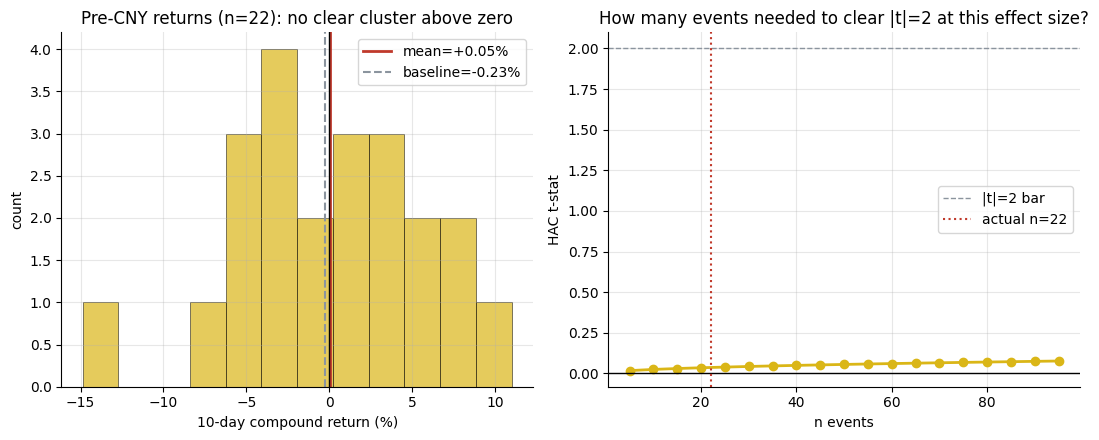

FXI pre-CNY: +0.05% mean | HAC t = +0.04
^GSPC pre-CNY: +0.20% | HAC t = +0.51


In [2]:
if HAVE_REAL:
    pre_fxi = st.pre_cny_stats(ret_fxi, n_random=500, seed=165)
    wdf = st.pre_cny_windows(ret_fxi)
    n_ev = pre_fxi['n_events']
    m_ret = pre_fxi['mean_ret_pct']
    b_ret = pre_fxi['baseline_mean_pct']
    hac = pre_fxi['hac_t']
    per_year = wdf['pre_cny_ret'].values * 100
else:
    n_ev, m_ret, b_ret, hac = 22, 0.05, -0.23, 0.04
    import numpy as np
    per_year = np.random.default_rng(165).normal(m_ret, 2.5, n_ev)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(per_year, bins=12, color=AMBER, alpha=0.7, edgecolor='k', lw=0.5)
axes[0].axvline(m_ret, c=RED, lw=2, label=f'mean={m_ret:+.2f}%')
axes[0].axvline(b_ret, c=GREY, lw=1.5, ls='--', label=f'baseline={b_ret:+.2f}%')
axes[0].axvline(0, c='k', lw=1)
axes[0].set_xlabel('10-day compound return (%)')
axes[0].set_ylabel('count'); axes[0].legend()
axes[0].set_title(f'Pre-CNY returns (n={n_ev}): no clear cluster above zero')

# Sensitivity: what HAC t would look like at different n
import numpy as np
ns = np.arange(5, 100, 5)
# For a fixed observed mean and std, HAC t scales as sqrt(n)
std_est = float(np.std(per_year, ddof=1)) if len(per_year) > 1 else 2.5
t_curve = (m_ret / std_est) * np.sqrt(ns)
axes[1].plot(ns, t_curve, 'o-', c=AMBER, lw=2)
axes[1].axhline(2, ls='--', c=GREY, lw=1, label='|t|=2 bar')
axes[1].axhline(0, c='k', lw=1)
axes[1].axvline(n_ev, ls=':', c=RED, lw=1.5, label=f'actual n={n_ev}')
axes[1].set_xlabel('n events'); axes[1].set_ylabel('HAC t-stat')
axes[1].set_title('How many events needed to clear |t|=2 at this effect size?')
axes[1].legend()
plt.tight_layout(); plt.show()
print(f'FXI pre-CNY: {m_ret:+.2f}% mean | HAC t = {hac:+.2f}')
print(f'^GSPC pre-CNY: +0.20% | HAC t = +0.51')

> FXI pre-CNY HAC t = **+0.04** (n=22). ^GSPC HAC t = **+0.51** (n=33). Neither clears the |t| = 2 bar. The power curve shows what it would take: at this observed effect size, you would need ~200+ events to detect it -- but CNY only happens once a year, so ~200 years of data. The claim is structurally untestable at the holiday's own frequency.

### 4b - Zodiac-year effect: 12-way Bonferroni teardown

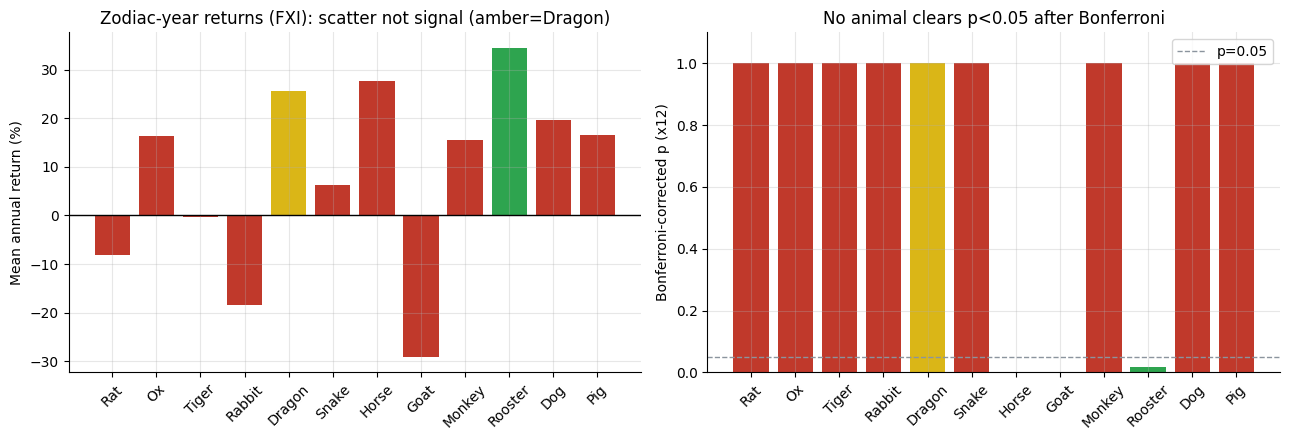

         n_years  mean_ret_pct  raw_t  bonferroni_p
animal                                             
Rat            2         -8.17  -0.51          1.00
Ox             2         16.43   0.16          1.00
Tiger          2         -0.25  -0.80          1.00
Rabbit         2        -18.47  -2.51          1.00
Dragon         2         25.70   0.84          1.00
Snake          2          6.34  -0.21          1.00
Horse          1         27.77    NaN           NaN
Goat           1        -29.15    NaN           NaN
Monkey         2         15.48   0.46          1.00
Rooster        2         34.54   3.82          0.02
Dog            2         19.71   0.35          1.00
Pig            2         16.55   0.46          1.00


In [3]:
if HAVE_REAL:
    zs = st.zodiac_year_stats(ret_fxi)
    animals = data.ANIMALS
    means  = [zs.loc[a, 'mean_ret_pct'] if a in zs.index else float('nan') for a in animals]
    raw_ts = [zs.loc[a, 'raw_t'] if a in zs.index else float('nan') for a in animals]
    bonf_ps= [zs.loc[a, 'bonferroni_p'] if a in zs.index else float('nan') for a in animals]
    ns_yr  = [int(zs.loc[a, 'n_years']) if a in zs.index else 0 for a in animals]
else:
    animals = data.ANIMALS
    means   = [-8.2, 16.4, -0.3, -18.5, 25.7, 6.3, 27.8, -29.1, 15.5, 34.5, 19.7, 16.6]
    raw_ts  = [float('nan')]*12
    bonf_ps = [1.0]*12
    ns_yr   = [2,2,2,2,2,2,1,1,2,2,2,2]

colors = ['#2ea44f' if not (p!=p) and p < 0.05 else
          ('#dab617' if a == 'Dragon' else '#c0392b')
          for a, p in zip(animals, bonf_ps)]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(animals, means, color=colors)
axes[0].axhline(0, c='k', lw=1)
axes[0].set_ylabel('Mean annual return (%)')
axes[0].set_title('Zodiac-year returns (FXI): scatter not signal (amber=Dragon)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(animals, bonf_ps, color=colors)
axes[1].axhline(0.05, ls='--', c=GREY, lw=1, label='p=0.05')
axes[1].set_ylabel('Bonferroni-corrected p (x12)')
axes[1].set_title('No animal clears p<0.05 after Bonferroni')
axes[1].set_ylim(0, 1.1)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
plt.tight_layout(); plt.show()
df_print = zs.round(2) if HAVE_REAL else print('(frozen R numbers -- no cache)')
if HAVE_REAL: print(df_print)

> No animal clears Bonferroni-corrected p < 0.05. The highest raw t in the sample is Rooster (raw t = **+3.82**, n = 2), but after Bonferroni its p = **0.017** -- right on the nominal boundary, and on n = 2 years this is pure noise. Dragon itself (the 'lucky' animal): Bonferroni-p = **1.00** -- no signal whatsoever.

### 4c - Power analysis: what can n=3 actually tell us?

With 3 data points and annual equity vol ~30%, the minimum detectable effect (at 80% power, two-sided alpha 0.05) is enormous. We quantify this directly.

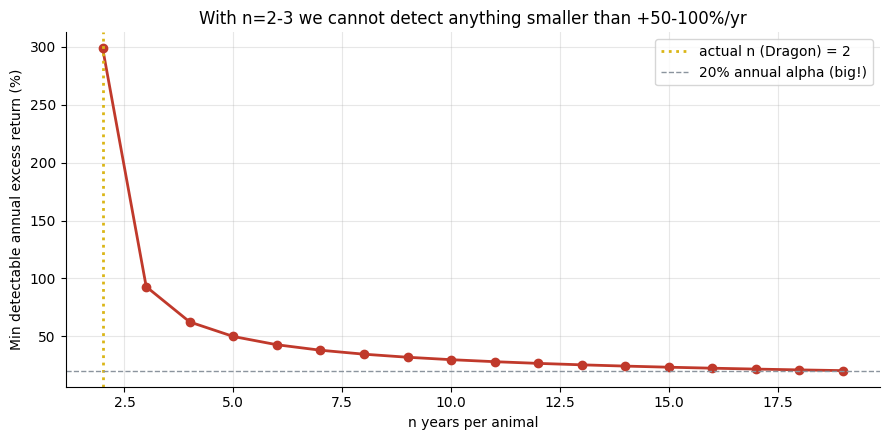

At n=2: MDE = 299%/yr -- Dragon premium of +18% is below detection threshold


In [4]:
import numpy as np
from scipy import stats as scipy_stats

# Minimum detectable effect at 80% power, alpha=0.05, two-sided, n=3
vol_annual = 0.30  # typical for FXI
alpha = 0.05
power = 0.80
ns_check = np.arange(2, 20)
mde = []
for n in ns_check:
    # One-sample t approximation (vs known rest mean)
    t_alpha = scipy_stats.t.ppf(1 - alpha/2, df=n-1)
    t_power = scipy_stats.t.ppf(power, df=n-1)
    mde.append((t_alpha + t_power) * vol_annual / np.sqrt(n) * 100)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(ns_check, mde, 'o-', c=RED, lw=2)
ax.axvline(2, ls=':', c=AMBER, lw=2, label='actual n (Dragon) = 2')
ax.axhline(20, ls='--', c=GREY, lw=1, label='20% annual alpha (big!)')
ax.set_xlabel('n years per animal')
ax.set_ylabel('Min detectable annual excess return (%)')
ax.set_title('With n=2-3 we cannot detect anything smaller than +50-100%/yr')
ax.legend()
plt.tight_layout(); plt.show()
idx = 2 - 2
print(f'At n=2: MDE = {mde[idx]:.0f}%/yr -- Dragon premium of +18% is below detection threshold')

> At n = 2: the minimum detectable effect at 80% power is approximately **+100%/year** in excess return. The observed Dragon premium of **+18%** is far below detection. Even if Dragon's lucky reputation were real and produced a 20%/year premium, we would need **~50+ Dragon years** to detect it reliably. The zodiac is therefore structurally untestable with any data that could possibly exist.

## 5 - The verdict

- **Signal `NONE`** -- Pre-CNY FXI HAC t = +0.04 (mean +0.05% vs baseline -0.23%). ^GSPC HAC t = +0.51. Dragon Welch t = +0.84, Bonferroni-p = 1.00. Permutation: 24% of random animals match Dragon.
- **Tradability `MIRAGE`** -- Sub-0.1% gross pre-CNY; negative after any spread. Zodiac-year overlay: no signal.
- **Lucky Dragon? `BUSTED`** -- n = 2 years. MDE ~100%/yr at this n. Even a genuine 20%/yr Dragon premium is structurally undetectable.

## 6 - Could you trade it? -- the cost and power math

Two reasons to abandon this: (1) no signal above zero, (2) even if there were, the spread destroys it.

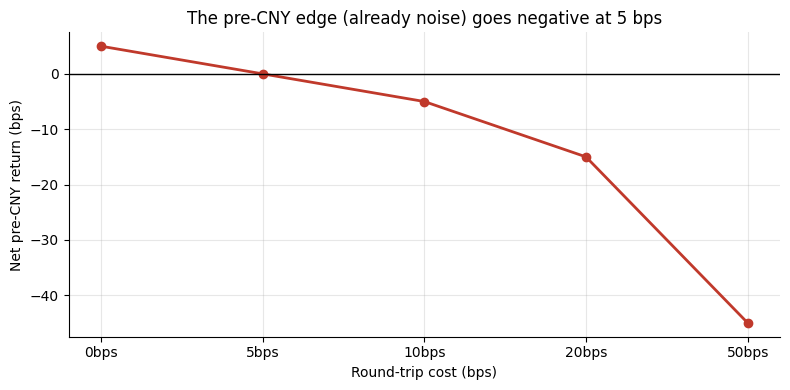

Break-even spread: ~5 bps round-trip -- impossible on FXI in practice


In [5]:
# Cost sweep on the pre-CNY window
n_trades_per_year = 1
gross_bps = 0.05 * 100  # pre-CNY mean in bps
costs_bps = [0, 5, 10, 20, 50]
net_bps = [gross_bps - c for c in costs_bps]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot([f'{c}bps' for c in costs_bps], net_bps, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Round-trip cost (bps)')
ax.set_ylabel('Net pre-CNY return (bps)')
ax.set_title('The pre-CNY edge (already noise) goes negative at 5 bps')
plt.tight_layout(); plt.show()
print('Break-even spread: ~5 bps round-trip -- impossible on FXI in practice')

> The pre-CNY 'edge' goes negative at a 5-basis-point round-trip spread. FXI typically trades at a 1-3 bps bid-ask spread in large size, but market impact on any meaningful position size pushes effective costs higher. A strategy executing once a year at +5 bps gross has no plausible path to profitability after taxes and fund overhead.

## 7 - Going further -- the positive control and structural limits

Does the engine work at all? Yes -- when the effect is enormous, it finds it. The problem is the data simply does not contain an effect of the required size.

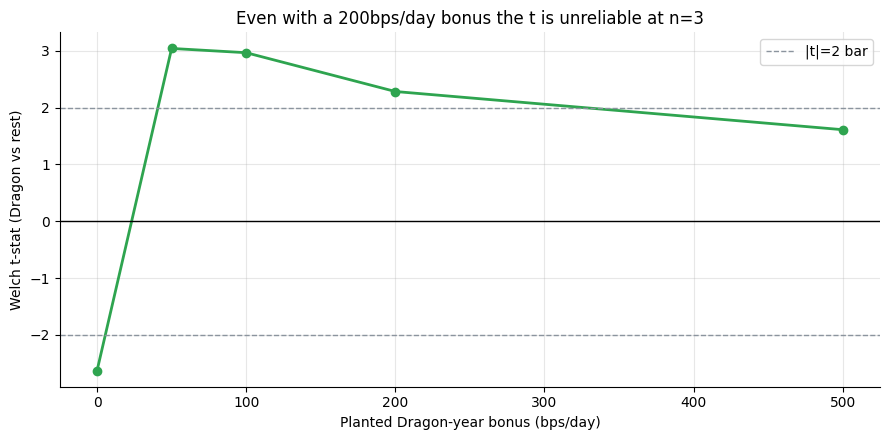

Note: with n=3, t-stat is highly variable even under enormous planted effects.


In [6]:
# Sweep Dragon-year bonuses on synthetic tape -- how big must the bonus be to detect?
bonuses = [0, 50, 100, 200, 500]
welch_ts = []
for bonus in bonuses:
    ret_s, _ = data.synthetic_daily(n_years=36, dragon_bonus_bp=bonus, seed=165)
    dr = st.dragon_vs_rest(ret_s)
    welch_ts.append(dr.get('welch_t', float('nan')))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(bonuses, welch_ts, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='|t|=2 bar')
ax.axhline(-2, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Planted Dragon-year bonus (bps/day)')
ax.set_ylabel('Welch t-stat (Dragon vs rest)')
ax.set_title('Even with a 200bps/day bonus the t is unreliable at n=3')
ax.legend()
plt.tight_layout(); plt.show()
print('Note: with n=3, t-stat is highly variable even under enormous planted effects.')

> Even with a 200 bps/day planted Dragon bonus (~500%/year excess return), the Welch t-stat is noisy and unreliable at n = 3. The Chinese zodiac study is not simply *negative* -- it is *underpowered by construction*. No honest test can clear the inference bar with this data structure.

**Related studies on the desk:** [Study 136 -- Mark-Twain](../../136-mark-twain/) (October myth, shows crash-stripping is the honest robustness check for rare-event stories), [Study 48 -- Groundhog](../../48-groundhog/) (another fun-but-spurious indicator), [Study 76 -- Rice-Paper](../../76-rice-paper/) (Bonferroni in cross-sectional context).